# Studying the final neutron star population

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rc
import matplotlib as mpl

# Set `usetex=False' if you do not have LaTeX installed.
rc('text', usetex=True)
rc('font', family='serif')
mpl.rcParams['text.latex.preamble'] = [r"\usepackage{amsmath}"]

In [2]:
rcParams["mathtext.fontset"] = "stix"
# rcParams["font.family"] = "Liberation serif"
rcParams["font.size"] = "25"
# rcParams['font.weight']='bold'
rcParams["figure.figsize"] = "8.0, 8.0"
rcParams["figure.autolayout"] = "False"

rcParams["axes.linewidth"] = "1.7"
rcParams["axes.labelpad"] = "15.0"
rcParams["axes.titlepad"] = "15.0"

rcParams["xtick.direction"] = "in"
rcParams["xtick.top"] = True
rcParams["xtick.major.pad"] = "10.0"
rcParams["xtick.minor.pad"] = "10.0"
rcParams["xtick.major.size"] = "10.0"
rcParams["xtick.major.width"] = "1.7"
rcParams["xtick.minor.size"] = "5.0"
rcParams["xtick.minor.width"] = "1.7"
rcParams["xtick.labelsize"] = "25"

rcParams["ytick.direction"] = "in"
rcParams["ytick.right"] = True
rcParams["ytick.major.pad"] = "10.0"
rcParams["ytick.minor.pad"] = "10.0"
rcParams["ytick.major.size"] = "10.0"
rcParams["ytick.major.width"] = "1.7"
rcParams["ytick.minor.size"] = "5.0"
rcParams["ytick.minor.width"] = "1.7"
rcParams["ytick.labelsize"] = "25"

Select an `final_population.txt` file to import:

In [3]:
data = pd.read_csv("../data/final_population.txt", header=[0,1])
data.head()

,age,r,phi,x,y,z,v_r,v_phi,v_z
,[yr],[kpc],[rad],[kpc],[kpc],[kpc],[km / s],[km / s],[km / s]
0,4.129277e+07,30.868217,5.473007,21.279597,-22.361251,10.599255,848.160513,-34.924387,237.372852
1,8.491184e+07,16.734376,8.646786,-11.920303,11.745029,0.431944,182.955469,-157.063415,-43.186802
2,2.312859e+07,9.755592,2.614521,-8.431598,4.907109,-12.727479,272.853206,-53.224508,-514.925145
3,1.649500e+07,25.473475,6.186089,25.353492,-2.469493,2.398431,604.691981,-189.974952,142.330938
4,5.284807e+07,9.871320,-1.549436,0.210838,-9.869068,-7.023867,59.296095,-53.829338,-58.195969


In [4]:
data = data[1:]
data.head()

,age,r,phi,x,y,z,v_r,v_phi,v_z
,[yr],[kpc],[rad],[kpc],[kpc],[kpc],[km / s],[km / s],[km / s]
1,8.491184e+07,16.734376,8.646786,-11.920303,11.745029,0.431944,182.955469,-157.063415,-43.186802
2,2.312859e+07,9.755592,2.614521,-8.431598,4.907109,-12.727479,272.853206,-53.224508,-514.925145
3,1.649500e+07,25.473475,6.186089,25.353492,-2.469493,2.398431,604.691981,-189.974952,142.330938
4,5.284807e+07,9.871320,-1.549436,0.210838,-9.869068,-7.023867,59.296095,-53.829338,-58.195969
5,5.547932e+07,33.453411,6.510666,32.591572,7.544543,17.720645,534.205474,-192.258762,297.661471


In [5]:
r = data["r"]["[kpc]"].to_numpy()
phi = data["phi"]["[rad]"].to_numpy()
x = data["x"]["[kpc]"].to_numpy()
y = data["y"]["[kpc]"].to_numpy()
z = data["z"]["[kpc]"].to_numpy()

Top view of the galactic plane

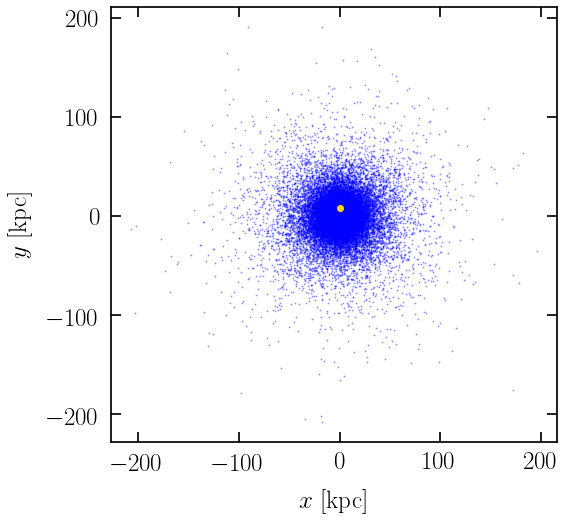

In [6]:
fig, ax = plt.subplots()

ax.plot(
    x,
    y,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=False
)

ax.plot(0.0, 8.5, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$y$ [kpc]")

plt.show()

Zoomed-in top view of the galactic plane

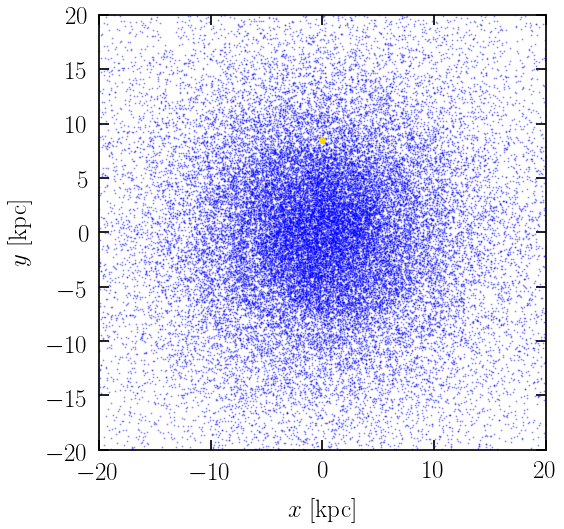

In [7]:
fig, ax = plt.subplots()

ax.plot(
    x,
    y,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=False
)

ax.plot(0.0, 8.5, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$y$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

Side view of the galactic plane

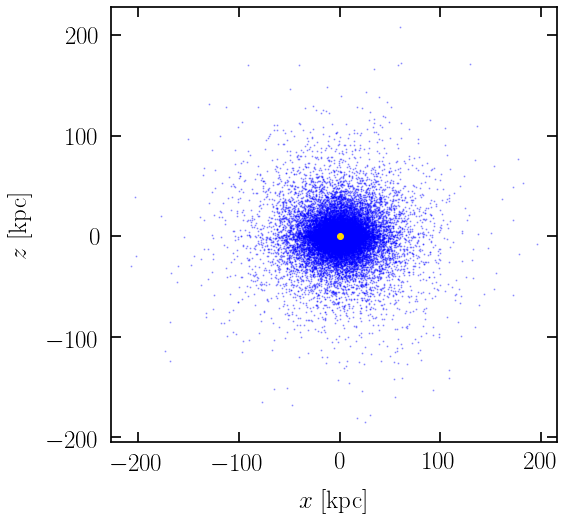

In [8]:
fig, ax = plt.subplots()

ax.plot(
    x,
    z,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.plot(0.0, 0.02, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$z$ [kpc]")

plt.show()

Zoomed-in side view of the galactic plane

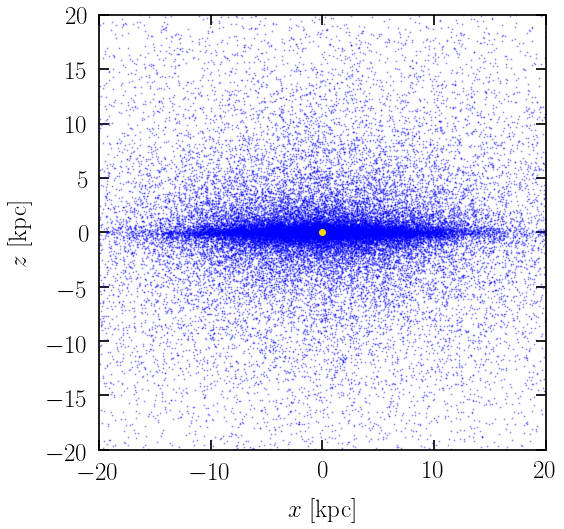

In [9]:
fig, ax = plt.subplots()

ax.plot(
    x,
    z,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.plot(0.0, 0.02, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$z$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

Histrogramming the pulsars position and comparing to underlying initial position PDF

In [10]:
def pdf_r(r):
    "pdf from the Milky Way stellar surface density (Yusifov & Küçük 2004)"
    A = 37.6  # [stars kpc^-2]
    R1 = 0.55  # +-0.1 [kpc]
    Rsun = 8.5
    a = 1.64  # +-0.11
    b = 4.01  # +-0.24
    rho = (
        A
        * ((r + R1) / (Rsun + R1)) ** a
        * np.exp(-b * ((r - Rsun) / (Rsun + R1)))
    )
    pdf_r = 2 * np.pi * r * rho
    return pdf_r

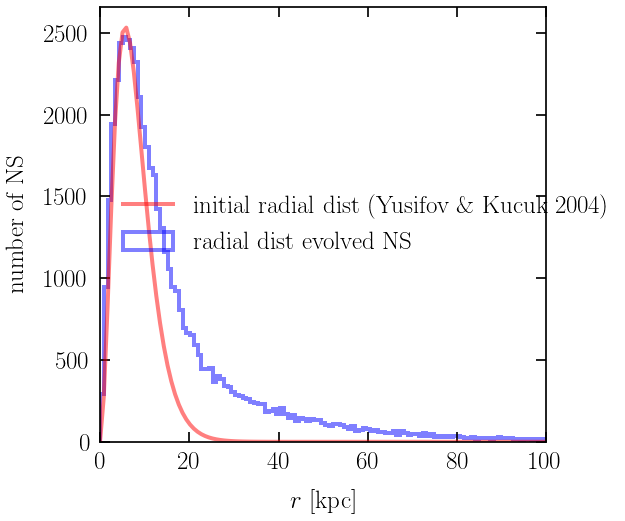

In [11]:
# r_bins = np.logspace(np.log10(0.0001), np.log10(100.), 100)
r_bins = np.linspace(0.0, 100.0, 120)

fig, ax = plt.subplots()

ax.hist(
    r,
    bins=r_bins,
    histtype="step",
    edgecolor="blue",
    lw=4,
    alpha=0.5,
    label="radial dist evolved NS",
)
ax.plot(
    r_bins,
    pdf_r(r_bins),
    linestyle="-",
    lw=4,
    color="red",
    alpha=0.5,
    label="initial radial dist (Yusifov \& Kucuk 2004)",
)
plt.xlabel(r"$r$ [kpc]")
plt.ylabel(r"number of NS")
plt.xlim(0.0, 100.0)
plt.legend(frameon=False, loc=0)

plt.show()